<a href="https://colab.research.google.com/github/Ziyi-star/Bachelorarbeit/blob/main/notebooks/training/train_1s_30hz_2class_real_world_phase_1_to_3_version_b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Training using real world data phase 1 to 3

## 1. VSCode: data loading

In [ ]:

%load_ext autoreload
%autoreload 2

import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import simclr_utitlities
import transformations
import simclr_models
import sys
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

sys.path.append('../')   # Add parent directory to Python path
working_directory = "../models/"
sys.path.append('../../')
from utils.preprocessing import *

seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

In [ ]:
# Save combined balanced data as pickle file
with open('../training_data/lab_real_world_2class_balanced_version_b/X_train_normalized.pkl', 'wb') as f:
    np_train_balanced_data = pickle.load(f)


Saved combined balanced data with shape: (2048, 30, 3)


In [ ]:
# load unbalanced data
with open('../training_data/lab_real_world_2class_unbalanced_version_b/X_train_normalized.pkl', 'rb') as f:
    np_train_unbalanced_data = pickle.load(f)
with open('../training_data/lab_real_world_2class_unbalanced_version_b/y_train_onehot.pkl', 'rb') as f:
    np_train_unbalanced_labels = pickle.load(f)
with open('../training_data/lab_real_world_2class_unbalanced_version_b/X_val_normalized.pkl', 'rb') as f:
    np_val_unbalanced_data = pickle.load(f)
with open('../training_data/lab_real_world_2class_unbalanced_version_b/y_val_onehot.pkl', 'rb') as f:
    np_val_unbalanced_labels = pickle.load(f)
with open('../training_data/lab_real_world_2class_unbalanced_version_b/X_test_normalized.pkl', 'rb') as f:
    np_test_unbalanced_data = pickle.load(f)
with open('../training_data/lab_real_world_2class_unbalanced_version_b/y_test_onehot.pkl', 'rb') as f:
    np_test_unbalanced_labels = pickle.load(f)
np_train_unbalanced_data.shape, np_train_unbalanced_labels.shape, np_val_unbalanced_data.shape, np_val_unbalanced_labels.shape, np_test_unbalanced_data.shape, np_test_unbalanced_labels.shape

((27877, 30, 3),
 (27877, 2),
 (6970, 30, 3),
 (6970, 2),
 (3441, 30, 3),
 (3441, 2))

In [ ]:
# For Google Colab

In [1]:
# 1. Clone your repository to go to access your notebook and .py files
!git clone https://github.com/Ziyi-star/Bachelorarbeit.git
# 2. Change working directory to where your notebook and .py files are
import os
os.chdir('/content/Bachelorarbeit/notebooks/training')
import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import simclr_utitlities
import transformations
import simclr_models
import sys
sys.path.append('../../')
from utils.preprocessing import *



seed = 1
tf.random.set_seed(seed)
np.random.seed(seed)

# Load balanced data for simclr pretraining
# Download the file from GitHub
!rm -f *.pkl # Remove existing pickle files
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/lab_real_world_2class_balanced_version_b/X_train_normalized.pkl

working_directory = "../models/"  # Relative path to models folder

# Load as usual
import pickle

with open('X_train_normalized.pkl', 'rb') as f:
    np_train_balanced_data = pickle.load(f)

print(np_train_balanced_data.shape)

Cloning into 'Bachelorarbeit'...
remote: Enumerating objects: 1533, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 1533 (delta 4), reused 9 (delta 3), pack-reused 1515 (from 2)
Receiving objects: 100% (1533/1533), 392.42 MiB | 13.52 MiB/s, done.
Resolving deltas: 100% (878/878), done.
Updating files: 100% (66/66), done.


/content/Bachelorarbeit/notebooks/training/transformations.py:35: SyntaxWarning: invalid escape sequence '\&'
  @inproceedings{TerryUm_ICMI2017, author = {Um, Terry T. and Pfister, Franz M. J. and Pichler, Daniel and Endo, Satoshi and Lang, Muriel and Hirche, Sandra and Fietzek, Urban and Kuli\'{c}, Dana}, title = {Data Augmentation of Wearable Sensor Data for Parkinson's Disease Monitoring Using Convolutional Neural Networks}, booktitle = {Proceedings of the 19th ACM International Conference on Multimodal Interaction}, series = {ICMI 2017}, year = {2017}, isbn = {978-1-4503-5543-8}, location = {Glasgow, UK}, pages = {216--220}, numpages = {5}, doi = {10.1145/3136755.3136817}, acmid = {3136817}, publisher = {ACM}, address = {New York, NY, USA}, keywords = {Parkinson\&#39;s disease, convolutional neural networks, data augmentation, health monitoring, motor state detection, wearable sensor}, }


--2025-12-08 10:31:12--  https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/lab_real_world_2class_balanced_version_b/X_train_normalized.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1525845 (1.5M) [application/octet-stream]
Saving to: ‘X_train_normalized.pkl’

X_train_normalized. 100%[===================>]   1.46M  --.-KB/s    in 0.008s  

2025-12-08 10:31:12 (175 MB/s) - ‘X_train_normalized.pkl’ saved [1525845/1525845]

(2119, 30, 3)


In [5]:
# Load unbalanced data for evluation
# Download the file from GitHub
!rm -f *.pkl # Remove existing pickle files
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/lab_real_world_2class_unbalanced_version_b/X_train_normalized.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/lab_real_world_2class_unbalanced_version_b/y_train_onehot.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/lab_real_world_2class_unbalanced_version_b/X_val_normalized.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/lab_real_world_2class_unbalanced_version_b/y_val_onehot.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/lab_real_world_2class_unbalanced_version_b/X_test_normalized.pkl
!wget https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/lab_real_world_2class_unbalanced_version_b/y_test_onehot.pkl


working_directory = "../models/"  # Relative path to models folder


# Load as usual
import pickle

with open('X_train_normalized.pkl', 'rb') as f:
    np_train_unbalanced_data = pickle.load(f)
with open('y_train_onehot.pkl', 'rb') as f:
    np_train_unbalanced_labels = pickle.load(f)
with open('X_val_normalized.pkl', 'rb') as f:
    np_val_unbalanced_data = pickle.load(f)
with open('y_val_onehot.pkl', 'rb') as f:
    np_val_unbalanced_labels = pickle.load(f)
with open('X_test_normalized.pkl', 'rb') as f:
    np_test_unbalanced_data = pickle.load(f)
with open('y_test_onehot.pkl', 'rb') as f:
    np_test_unbalanced_labels = pickle.load(f)

print(np_train_unbalanced_data.shape, np_train_unbalanced_labels.shape)
print(np_val_unbalanced_data.shape, np_val_unbalanced_labels.shape)
print(np_test_unbalanced_data.shape, np_test_unbalanced_labels.shape)

--2025-12-08 10:31:59--  https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/lab_real_world_2class_unbalanced_version_b/X_train_normalized.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 20071605 (19M) [application/octet-stream]
Saving to: ‘X_train_normalized.pkl’

X_train_normalized. 100%[===================>]  19.14M  --.-KB/s    in 0.04s   

2025-12-08 10:31:59 (501 MB/s) - ‘X_train_normalized.pkl’ saved [20071605/20071605]

--2025-12-08 10:31:59--  https://raw.githubusercontent.com/Ziyi-star/Bachelorarbeit/main/notebooks/training_data/lab_real_world_2class_unbalanced_version_b/y_train_onehot.pkl
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.108.133, ...

# SimCLR Training

## 1.1 Pretraining with SimCLR

In [10]:
# Parameters for all experiments
window_size = 30
input_shape = (window_size, 3)
batch_size = 128
#Number of samples processed together in one training step. Larger batch sizes can speed up training but require more memory.
decay_steps = 1000
#Number of steps after which the learning rate decays (used for learning rate scheduling).
epochs = 100
temperature = 0.1


In [11]:
#A parameter for the SimCLR loss function that controls how sharply similarities are measured.
# transform_funcs = [
#     transformations.scaling_transform_vectorized, # Use Scaling trasnformation
#     transformations.rotation_transform_vectorized # Use rotation trasnformation
# ]
transform_funcs = [
    transformations.time_segment_permutation_transform_improved,
    transformations.channel_shuffle_transform_vectorized
]
#List of data augmentation functions to apply to the input data. Here, only rotation is used.
transformation_function = simclr_utitlities.generate_composite_transform_function_simple(transform_funcs)

0 <function time_segment_permutation_transform_improved at 0x797e57d765c0>
1 <function channel_shuffle_transform_vectorized at 0x797e57d76520>


In [12]:
# Time
start_time = datetime.datetime.now()
start_time_str = start_time.strftime("%Y%m%d-%H%M%S")
#Formats the date and time as a string like 20250827-153045 (for filenames, logs, etc.).
tf.keras.backend.set_floatx('float32')
#Sets TensorFlow to use 32-bit floating point numbers for all computations (standard for deep learning).


In [13]:
# Create a cosine-decayed learning rate schedule and SGD optimizer for training.
lr_decayed_fn = tf.keras.optimizers.schedules.CosineDecay(initial_learning_rate=0.1, decay_steps=decay_steps)
optimizer = tf.keras.optimizers.SGD(lr_decayed_fn)

# Build the base model and attach the SimCLR head for contrastive learning.
base_model = simclr_models.create_base_model_small_dimensions(input_shape, model_name="base_model")
simclr_model = simclr_models.attach_simclr_head(base_model)
simclr_model.summary()

# Train the SimCLR model using the specified transformation function and optimizer.
trained_simclr_model, epoch_losses = simclr_utitlities.simclr_train_model(
    simclr_model,
    np_train_balanced_data,
    optimizer,
    batch_size,
    transformation_function,
    temperature=temperature,
    epochs=epochs,
    is_trasnform_function_vectorized=True,
    verbose=1
)

# Save the trained SimCLR model to disk for later use.
simclr_model_save_path = f"{working_directory}{start_time_str}_simclr.hdf5"
trained_simclr_model.save(simclr_model_save_path)

Model: "base_model_simclr"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 30, 32)         │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 30, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 30, 96)         │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 50)             │         6,450 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,594 (580.45 KB)

 Trainable params: 148,594 (580.45 KB)

 Non-trainable params: 0 (0.00 B)

epoch: 1 loss: 9.733
epoch: 2 loss: 7.962
epoch: 3 loss: 6.943
epoch: 4 loss: 5.970
epoch: 5 loss: 6.110
epoch: 6 loss: 5.281
epoch: 7 loss: 5.714
epoch: 8 loss: 5.196
epoch: 9 loss: 4.466
epoch: 10 loss: 4.438
epoch: 11 loss: 4.152
epoch: 12 loss: 3.976
epoch: 13 loss: 3.713
epoch: 14 loss: 3.703
epoch: 15 loss: 3.437
epoch: 16 loss: 3.224
epoch: 17 loss: 3.193
epoch: 18 loss: 2.824
epoch: 19 loss: 2.922
epoch: 20 loss: 2.665
epoch: 21 loss: 2.468
epoch: 22 loss: 2.630
epoch: 23 loss: 2.223
epoch: 24 loss: 2.228
epoch: 25 loss: 2.165
epoch: 26 loss: 2.056
epoch: 27 loss: 2.126
epoch: 28 loss: 1.894
epoch: 29 loss: 1.862
epoch: 30 loss: 1.764
epoch: 31 loss: 1.783
epoch: 32 loss: 1.669
epoch: 33 loss: 1.609
epoch: 34 loss: 1.644
epoch: 35 loss: 1.589
epoch: 36 loss: 1.562
epoch: 37 loss: 1.469
epoch: 38 loss: 1.430
epoch: 39 loss: 1.433
epoch: 40 loss: 1.354
epoch: 41 loss: 1.405
epoch: 42 loss: 1.357
epoch: 43 loss: 1.335
epoch: 44 loss: 1.274
epoch: 45 loss: 1.278
epoch: 46 loss: 1.2

epoch: 200 loss: 1.117


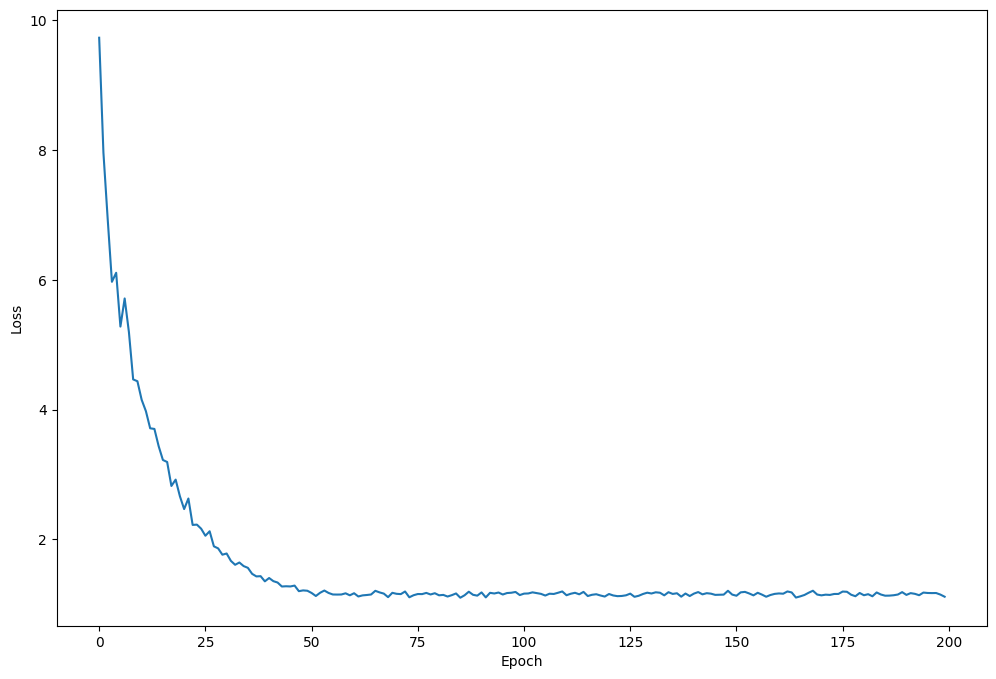

In [14]:
# Plot history of training losses over epochs.
plt.figure(figsize=(12,8))
plt.plot(epoch_losses)
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

## 1.2 Fine-tuning and Evaluation

### 1.2.1 Linear Model

#### Train

In [15]:
# This block performs linear evaluation on top of the pretrained SimCLR base model.
total_epochs = 50
batch_size = 128
tag = "linear_eval"
output_shape = np_train_unbalanced_labels.shape[1]  # Number of classes for classification

# 1. Loads the SimCLR model and attaches a linear classification head on top.
simclr_model = tf.keras.models.load_model(simclr_model_save_path)
linear_evaluation_model = simclr_models.create_linear_model_from_base_model(simclr_model, output_shape, intermediate_layer=7)

# 2. Sets up a ModelCheckpoint callback to save the best model (lowest validation loss).
# This ensures we keep the model version that performs best on validation data
linear_eval_best_model_file_name = f"{working_directory}{start_time_str}_simclr_{tag}.keras"
best_model_callback = tf.keras.callbacks.ModelCheckpoint(
    linear_eval_best_model_file_name,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    save_weights_only=False,
    verbose=0
)

# 3. Trains the linear evaluation model using the training and validation data.
training_history = linear_evaluation_model.fit(
    x = np_train_unbalanced_data,
    y = np_train_unbalanced_labels,
    batch_size=batch_size,
    shuffle=True,
    epochs=total_epochs,
    callbacks=[best_model_callback],
    validation_data=(np_val_unbalanced_data, np_val_unbalanced_labels)
)

Epoch 1/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - auc: 0.9772 - categorical_accuracy: 0.9682 - loss: 0.1792 - precision: 0.9682 - recall: 0.9682 - val_auc: 0.9895 - val_categorical_accuracy: 0.9700 - val_loss: 0.1137 - val_precision: 0.9700 - val_recall: 0.9700
Epoch 2/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.9851 - categorical_accuracy: 0.9688 - loss: 0.1201 - precision: 0.9688 - recall: 0.9688 - val_auc: 0.9911 - val_categorical_accuracy: 0.9681 - val_loss: 0.1112 - val_precision: 0.9681 - val_recall: 0.9681
Epoch 3/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.9863 - categorical_accuracy: 0.9685 - loss: 0.1169 - precision: 0.9685 - recall: 0.9685 - val_auc: 0.9926 - val_categorical_accuracy: 0.9725 - val_loss: 0.1000 - val_precision: 0.9725 - val_recall: 0.9725
Epoch 4/50
218/218 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - auc: 0.9879 - categorical_accuracy: 0.9688 - loss: 0.1126 - precision: 0.9688 - recall: 0.9688 - val_auc: 0.9929 - val_categorical_accuracy: 0.971

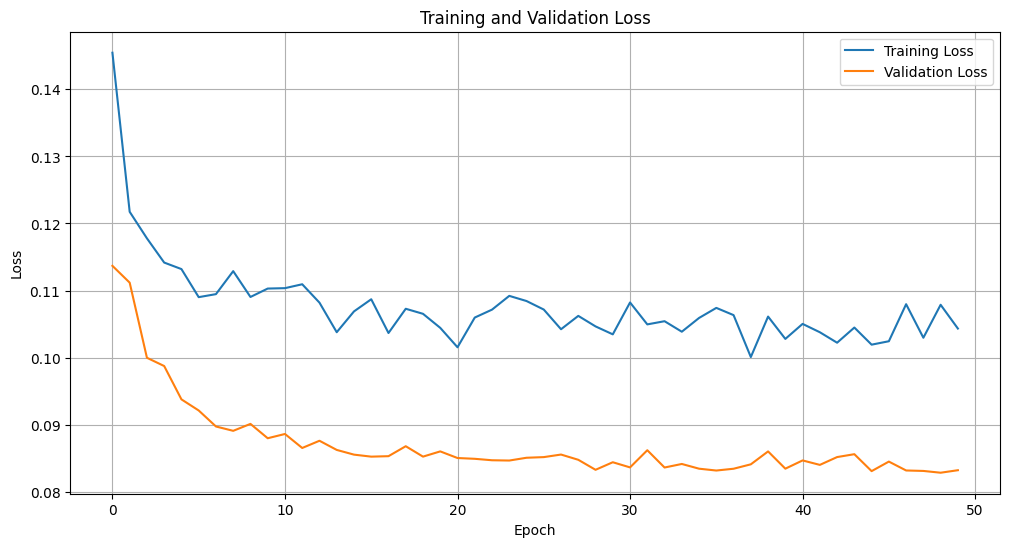

In [19]:
# Training and Validation Loss

plt.figure(figsize=(12,6))
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

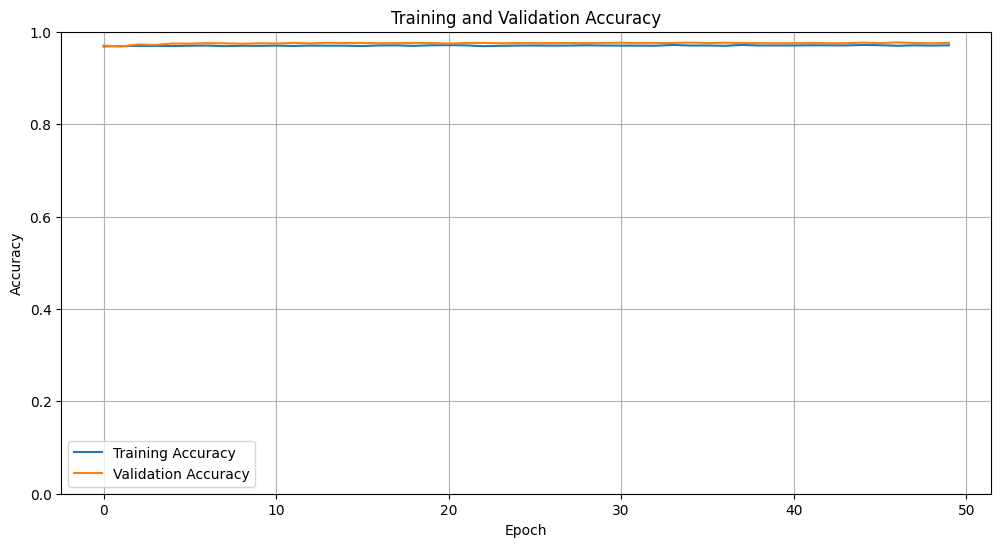

In [20]:
# Training and Validation Accuracy
plt.figure(figsize=(12,6))
plt.plot(training_history.history['categorical_accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_categorical_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.ylim([0, 1])
plt.show()

#### Test:

In [21]:
# Load models and evaluate on test set on vscode
linear_eval_model_path =  linear_eval_best_model_file_name

# Load both models
# simclr_model = tf.keras.models.load_model(simclr_model_path)
linear_eval_best_model = tf.keras.models.load_model(linear_eval_model_path)

In [22]:
linear_eval_best_model = tf.keras.models.load_model(linear_eval_best_model_file_name)

print("Model with lowest validation Loss:")
print(simclr_utitlities.evaluate_model_simple(linear_eval_best_model.predict(np_test_unbalanced_data), np_test_unbalanced_labels, return_dict=True))
print("Model in last epoch")
print(simclr_utitlities.evaluate_model_simple(linear_evaluation_model.predict(np_test_unbalanced_data), np_test_unbalanced_labels, return_dict=True))


Model with lowest validation Loss:
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
{'Confusion Matrix': array([[3301,   74],
       [  53,   13]]), 'F1 Macro': 0.5755305540257417, 'F1 Micro': 0.963092124382447, 'F1 Weighted': 0.9655674263829004, 'Precision': 0.5668116299631937, 'Recall': 0.5875218855218856, 'Kappa': np.float64(0.1514245935350076)}
Model in last epoch
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
{'Confusion Matrix': array([[3309,   66],
       [  54,   12]]), 'F1 Macro': 0.5744286138319976, 'F1 Micro': 0.96512641673932, 'F1 Weighted': 0.9665484287608207, 'Precision': 0.5688945309819529, 'Recall': 0.5811313131313132, 'Kappa': np.float64(0.148983528713459)}


### 1.2.2 Full HAR Model

#### Train

In [23]:
total_epochs = 50
batch_size = 256
tag = "full_eval"
output_shape = np_train_unbalanced_labels.shape[1]  # Number of classes for classification

simclr_model = tf.keras.models.load_model(simclr_model_save_path)
full_evaluation_model = simclr_models.create_full_classification_model_from_base_model(
    simclr_model, output_shape, model_name="TPN", intermediate_layer=7, last_freeze_layer=4)

full_eval_best_model_file_name = f"{working_directory}{start_time_str}_simclr_{tag}.keras"

best_model_callback = tf.keras.callbacks.ModelCheckpoint(full_eval_best_model_file_name,
    monitor='val_loss', mode='min', save_best_only=True, save_weights_only=False, verbose=0
)

training_history = full_evaluation_model.fit(
    x = np_train_unbalanced_data,
    y = np_train_unbalanced_labels,
    batch_size=batch_size,
    shuffle=True,
    epochs=total_epochs,
    callbacks=[best_model_callback],
    validation_data=(np_val_unbalanced_data, np_val_unbalanced_labels)
)



Epoch 1/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - auc: 0.9623 - categorical_accuracy: 0.9250 - loss: 0.2706 - precision: 0.9250 - recall: 0.9250 - val_auc: 0.9952 - val_categorical_accuracy: 0.9704 - val_loss: 0.0901 - val_precision: 0.9704 - val_recall: 0.9704
Epoch 2/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.9944 - categorical_accuracy: 0.9720 - loss: 0.0914 - precision: 0.9720 - recall: 0.9720 - val_auc: 0.9958 - val_categorical_accuracy: 0.9706 - val_loss: 0.0869 - val_precision: 0.9706 - val_recall: 0.9706
Epoch 3/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - auc: 0.9951 - categorical_accuracy: 0.9731 - loss: 0.0856 - precision: 0.9731 - recall: 0.9731 - val_auc: 0.9960 - val_categorical_accuracy: 0.9760 - val_loss: 0.0779 - val_precision: 0.9760 - val_recall: 0.9760
Epoch 4/50
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.9953 - categorical_accuracy: 0.9760 - loss: 0.0818 - precision: 0.9760 - recall: 0.9760 - val_auc: 0.9964 - val_categorical_accuracy: 0.978

#### Plot metrics

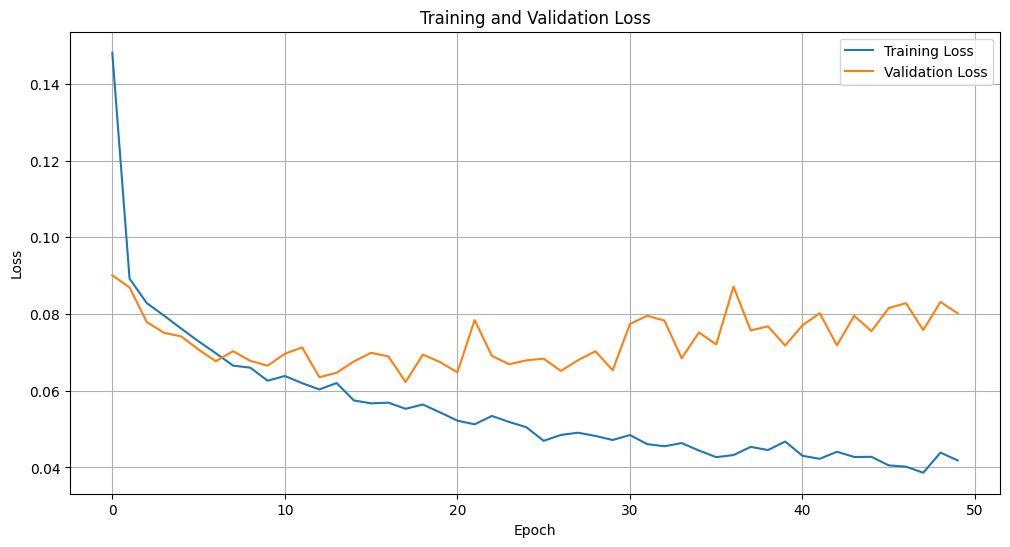

In [24]:
# Training and Validation Loss

plt.figure(figsize=(12,6))
plt.plot(training_history.history['loss'], label='Training Loss')
plt.plot(training_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

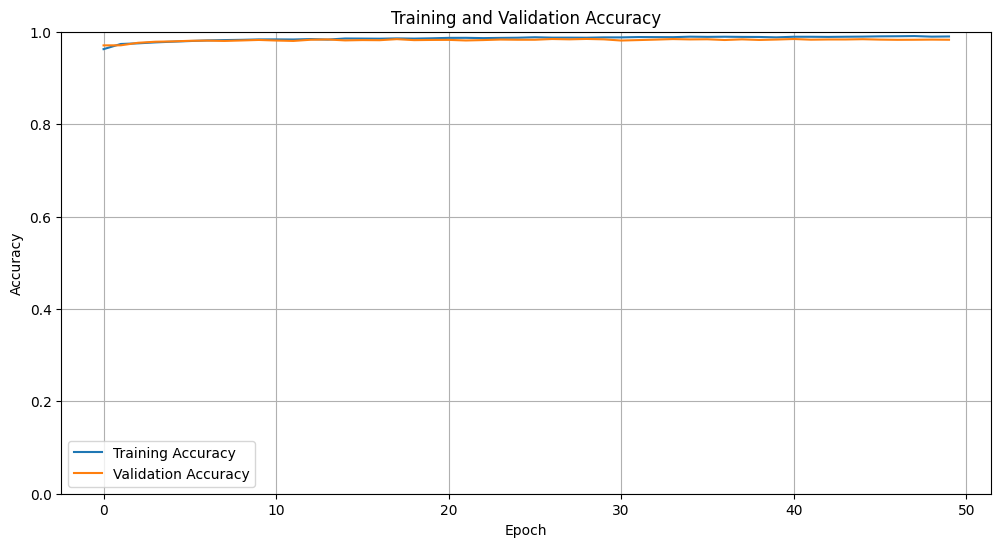

In [25]:
# Training and Validation Accuracy
plt.figure(figsize=(12,6))
plt.plot(training_history.history['categorical_accuracy'], label='Training Accuracy')
plt.plot(training_history.history['val_categorical_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.ylim([0, 1])
plt.show()

# Evaluation of real world test data

In [26]:
full_eval_best_model = tf.keras.models.load_model(full_eval_best_model_file_name)

print("Model with lowest validation Loss:")
print(simclr_utitlities.evaluate_model_simple(full_eval_best_model.predict(np_test_unbalanced_data), np_test_unbalanced_labels, return_dict=True))
print("Model in last epoch")
print(simclr_utitlities.evaluate_model_simple(full_evaluation_model.predict(np_test_unbalanced_data), np_test_unbalanced_labels, return_dict=True))

Model with lowest validation Loss:
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
{'Confusion Matrix': array([[3312,   63],
       [  54,   12]]), 'F1 Macro': 0.5764281453285232, 'F1 Micro': 0.9659982563208369, 'F1 Weighted': 0.967060720259907, 'Precision': 0.5719786096256685, 'Recall': 0.5815757575757575, 'Kappa': np.float64(0.15292847810032384)}
Model in last epoch
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
{'Confusion Matrix': array([[3290,   85],
       [  49,   17]]), 'F1 Macro': 0.591211328141623, 'F1 Micro': 0.9610578320255739, 'F1 Weighted': 0.9651258045705853, 'Precision': 0.5759958071278826, 'Recall': 0.6161952861952862, 'Kappa': np.float64(0.18336096233953925)}


#### Optimize

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
=== Threshold Analysis ===


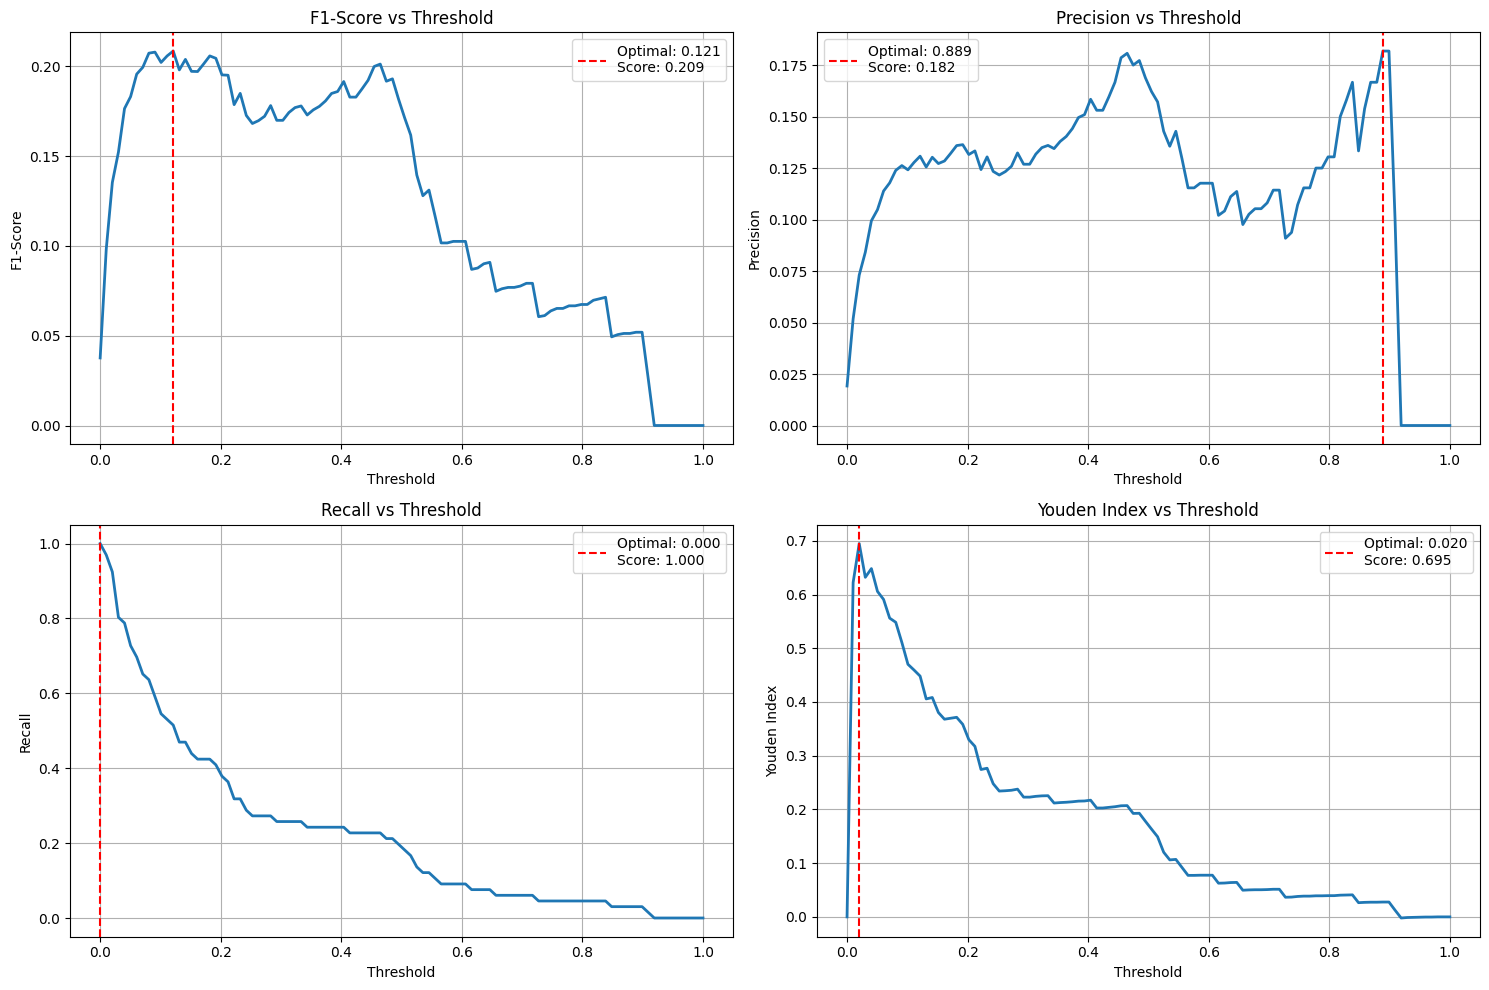


=== Optimal Thresholds ===
F1: Threshold = 0.121, Score = 0.209
PRECISION: Threshold = 0.889, Score = 0.182
RECALL: Threshold = 0.000, Score = 1.000
YOUDEN: Threshold = 0.020, Score = 0.695

=== Default Threshold (0.5) ===
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
{'Confusion Matrix': array([[3312,   63],
       [  54,   12]]), 'F1 Macro': 0.5764281453285232, 'F1 Micro': 0.9659982563208369, 'F1 Weighted': 0.967060720259907, 'Precision': 0.5719786096256685, 'Recall': 0.5815757575757575, 'Kappa': np.float64(0.15292847810032384)}

=== Optimal F1 Threshold (0.121) ===
108/108 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
{'Confusion Matrix': array([[3149,  226],
       [  32,   34]]), 'F1 Macro': 0.5846178464348679, 'F1 Micro': 0.9250217959895379, 'F1 Weighted': 0.9462219135540986, 'Precision': 0.5603547505622325, 'Recall': 0.7240942760942761, 'Kappa': np.float64(0.18361187590004469)}

=== Comparison: Linear vs Full Model ===
108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Linear Model - Optimal F1 Threshold:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def evaluate_with_threshold(model, X_test, y_test, threshold=0.5):
    """
    Evaluate model with custom threshold.
    """
    y_pred_proba = model.predict(X_test)
    y_pred = (y_pred_proba[:, 1] >= threshold).astype(int)

    # Convert to one-hot for evaluate_model_simple
    y_pred_onehot = np.zeros_like(y_pred_proba)
    y_pred_onehot[np.arange(len(y_pred)), y_pred] = 1

    results = simclr_utitlities.evaluate_model_simple(y_pred_onehot, y_test, return_dict=True)

    return results, y_pred_proba

In [ ]:
# Get predictions for both models
y_pred_proba = full_eval_best_model.predict(np_test_unbalanced_data)
y_pred_proba_linear = linear_eval_best_model.predict(np_test_unbalanced_data)

# Set threshold
threshold = 0.1

# Evaluate Full Model with threshold 0.1
print(f"\n=== Full Model - Threshold {threshold} ===")
results_full, _ = evaluate_with_threshold(full_eval_best_model, np_test_unbalanced_data, np_test_unbalanced_labels, threshold=threshold)
print(results_full)

# Evaluate Linear Model with threshold 0.1
print(f"\n=== Linear Model - Threshold {threshold} ===")
results_linear, _ = evaluate_with_threshold(linear_eval_best_model, np_test_unbalanced_data, np_test_unbalanced_labels, threshold=threshold)
print(results_linear)

# Compare both models
print("\n=== Comparison: Linear vs Full Model (Threshold 0.1) ===")
print(f"Linear Model - Threshold: {threshold}")
print(results_linear)
print(f"\nFull Model - Threshold: {threshold}")
print(results_full)

## Extra: t-SNE Plots

In [29]:
import sklearn.manifold
import seaborn as sns

### t-SNE Representations

In [30]:
# First load the model from the file path
target_model_path = simclr_model_save_path
loaded_model = tf.keras.models.load_model(target_model_path)
perplexity = 30.0

# Then extract the intermediate model
intermediate_model = simclr_models.extract_intermediate_model_from_base_model(loaded_model, intermediate_layer=7)
intermediate_model.summary()

# Continue with your t-SNE code
embeddings = intermediate_model.predict(np_test_unbalanced_data, batch_size=600)
tsne_model = sklearn.manifold.TSNE(perplexity=perplexity, verbose=1, random_state=42)
tsne_projections = tsne_model.fit_transform(embeddings)

Model: "base_model_simclr_layer_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 30, 32)         │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 30, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 30, 96)         │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 30, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,416 (329.75 KB)

 Trainable params: 84,416 (329.75 KB)

 Non-trainable params: 0 (0.00 B)

6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 161ms/step
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 3441 samples in 0.001s...
[t-SNE] Computed neighbors for 3441 samples in 0.345s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3441
[t-SNE] Computed conditional probabilities for sample 2000 / 3441
[t-SNE] Computed conditional probabilities for sample 3000 / 3441
[t-SNE] Computed conditional probabilities for sample 3441 / 3441
[t-SNE] Mean sigma: 0.039950
[t-SNE] KL divergence after 250 iterations with early exaggeration: 67.793518
[t-SNE] KL divergence after 1000 iterations: 0.978581


### Plotting

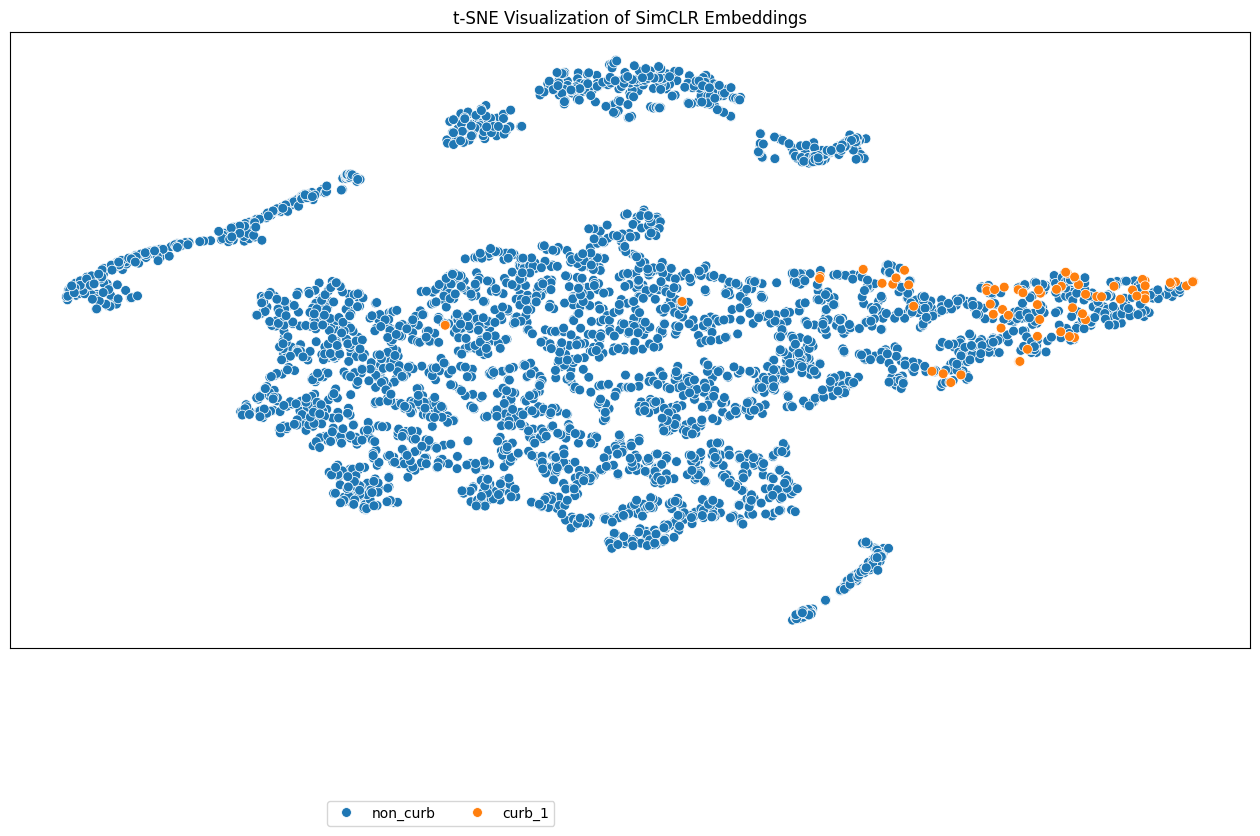

In [31]:
# Define colors
other_class_color = "#1f77b4"  # Blue
curb_1_color = "#ff7f0e"      # Yellow

# Get the true labels (class indices) from the one-hot encoded test labels
labels_argmax = np.argmax(np_test_unbalanced_labels, axis=1)
unique_labels = np.unique(labels_argmax)

# Create custom color palette
custom_palette = [other_class_color, curb_1_color]  # First color for non_curb (0), second for curb_1 (1)

# Create the t-SNE visualization
plt.figure(figsize=(16,8))
graph = sns.scatterplot(
    x=tsne_projections[:,0], y=tsne_projections[:,1],
    hue=labels_argmax,
    palette=custom_palette,  # Use custom palette instead of "hsv"
    s=50,
    alpha=1.0,
    rasterized=True
)
plt.xticks([], [])
plt.yticks([], [])

plt.title("t-SNE Visualization of SimCLR Embeddings")

# Define your activity names
label_list_full_name = ["non_curb", "curb_1"]

# Update legend with custom colors
try:
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)
    legend = graph.legend_
    if 'label_list_full_name' in globals():
        for j, label in enumerate(unique_labels):
            if label < len(label_list_full_name):
                legend.get_texts()[j].set_text(label_list_full_name[label])
except Exception as e:
    print(f"Warning: Could not customize legend - {e}")
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)